In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# sktime imports for forecasting
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.base.adapters._pgmpy.dbn_forecaster import PgmpyDBNForecaster

In [2]:
# Synthetic Data Generation 

# We create a simple, reproducible dataset to test the forecaster.
# The 'sales' variable depends on its previous value and a random 'discount_pct'.
# This creates a causal relationship that our model can learn.

np.random.seed(42)  
n = 100  
discount_pct = np.random.randint(1, 101, size=n)

sales = [100]
for t in range(1, n):
    # Noise is smaller relative to the base value
    noise = np.random.randint(-5, 6)
    # Autoregressive component is stable (less than 1.0)
    base = 0.95 * sales[-1] + 20
    # Exogenous influence is additive, not multiplicative
    adj = base + (discount_pct[t] / 5.0)
    sales.append(int(adj))

index = pd.date_range("2023-01-01", periods=n, freq="W")
df = pd.DataFrame({"sales": sales, "discount_pct": discount_pct}, index=index)
print("--- Synthetic Data ---")
print(df)


--- Synthetic Data ---
            sales  discount_pct
2023-01-01    100            52
2023-01-08    133            93
2023-01-15    149            15
2023-01-22    175            72
2023-01-29    198            61
...           ...           ...
2024-10-27    607            85
2024-11-03    612            80
2024-11-10    617            82
2024-11-17    616            53
2024-11-24    609            24

[100 rows x 2 columns]


In [3]:
# Data Preparation and Model Definition 

# Here, we prepare the inputs for our forecaster in the format sktime expects.
# 1. Define Target (y) and Exogenous Variables (X)
#    - y (the target) must be a pandas Series.
#    - X (features) must be a pandas DataFrame.

sales_bins = pd.cut(df["sales"], bins=10, labels=False, include_lowest=True)
discount_bins = pd.cut(df["discount_pct"], bins=5, labels=False, include_lowest=True)

y = sales_bins.rename("sales")
X = discount_bins.to_frame().rename(columns={"discount_pct": "discount_pct"})


# 2. Define the Network Structure
#    This is the core of the Bayesian Network model. We define the causal
#    relationships between variables across a 2-slice time window.
#    - A tuple `(variable, time_slice)` represents a node in the graph.
#    - `time_slice=0` is the "past" (t-1), and `time_slice=1` is the "present" (t).

structure = [
    # `sales` at t-1 (slice 1) causes `sales` at t (slice 0).
    (("sales", 1), ("sales", 0)),
    
    # `discount_pct` at t (slice 0) causes `sales` at t (slice 0).
    (("discount_pct", 0), ("sales", 0)),
]

# 3. Define the Forecasting Horizon (fh)
#    This sktime object specifies how many steps ahead we want to predict.
fh = ForecastingHorizon(range(1, 9))  # Predict the next 8 weeks.
print(f"X: {X}")
print(f"y: {y}")
print(f"structure: {structure}")
print(f"fh : {fh}")

X:             discount_pct
2023-01-01             2
2023-01-08             4
2023-01-15             0
2023-01-22             3
2023-01-29             3
...                  ...
2024-10-27             4
2024-11-03             3
2024-11-10             4
2024-11-17             2
2024-11-24             1

[100 rows x 1 columns]
y: 2023-01-01    0
2023-01-08    0
2023-01-15    0
2023-01-22    1
2023-01-29    1
             ..
2024-10-27    9
2024-11-03    9
2024-11-10    9
2024-11-17    9
2024-11-24    9
Freq: W-SUN, Name: sales, Length: 100, dtype: int64
structure: [(('sales', 1), ('sales', 0)), (('discount_pct', 0), ('sales', 0))]
fh : ForecastingHorizon(start=1, stop=9, step=1, is_relative=True)


In [4]:
# Instantiate, Fit, and Predict 


# 1. Instantiate the Forecaster
state_names = {
    "sales": list(range(10)),
    "discount_pct": list(range(5)),
}

fc = PgmpyDBNForecaster(
    structure=structure,
    max_lag=1,
    state_names=state_names  
)

# 2. Fit the Model
print("--- Fitting model... ---")
fc.fit(y=y, X=X, fh=fh)
print("Fit successful.\n")

# 3. Get Point Forecasts
#    Call the standard `predict()` method for point predictions.
print("--- Predicting next 8 steps... ---")
y_pred = fc.predict(fh=fh)
print("Forecasted Values:")
print(y_pred)

# 4. Get Prediction Intervals
print("\n--- Predicting with Intervals... ---")
y_pred_with_intervals = fc.predict_interval(fh=fh, coverage=0.90)
print(y_pred_with_intervals)


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered,O=Categorical Ordered)inferred from data: 
 {'sales_0': 'C', 'discount_pct_0': 'C', 'sales_1': 'C', 'discount_pct_1': 'C'}


--- Fitting model... ---
Fit successful.

--- Predicting next 8 steps... ---
Forecasted Values:
2024-12-01    9
2024-12-08    9
2024-12-15    9
2024-12-22    9
2024-12-29    9
2025-01-05    9
2025-01-12    9
2025-01-19    9
Freq: W-SUN, Name: sales, dtype: int64

--- Predicting with Intervals... ---
variable   sales      
coverage     0.9      
bound      lower upper
2024-12-01     8     9
2024-12-08     8     9
2024-12-15     8     9
2024-12-22     8     9
2024-12-29     8     9
2025-01-05     8     9
2025-01-12     8     9
2025-01-19     8     9


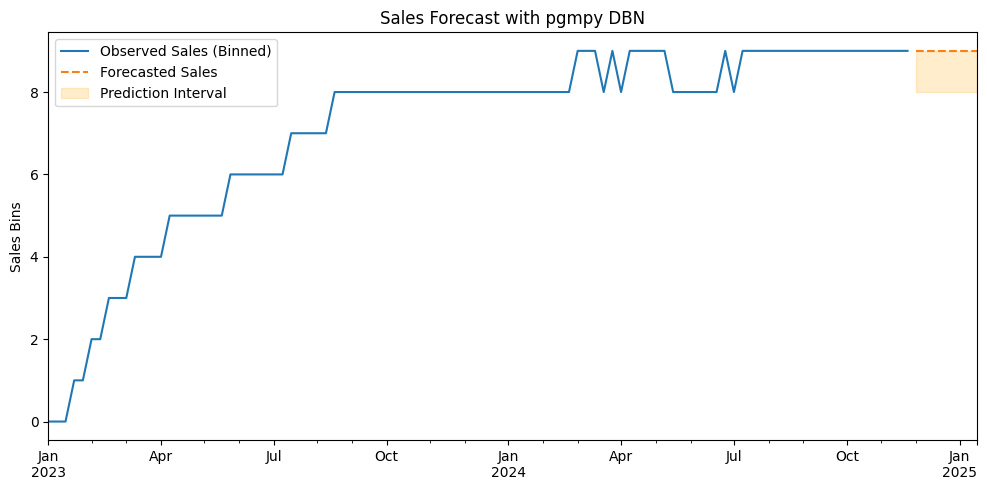

In [5]:
# Visualization 

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Plot the historical data
y.plot(ax=ax, label="Observed Sales (Binned)")

# Plot the point forecast
y_pred.plot(ax=ax, label="Forecasted Sales", style='--')

var_name = y.name    
coverage = 0.90         
ax.fill_between(
    y_pred_with_intervals.index,
    y_pred_with_intervals[(var_name, coverage, "lower")],
    y_pred_with_intervals[(var_name, coverage, "upper")],
    alpha=0.2,
    color="orange",
    label="Prediction Interval",
)

ax.set_title("Sales Forecast with pgmpy DBN")
ax.set_ylabel("Sales Bins") # Changed label to reflect binned data
ax.legend()
plt.tight_layout()
plt.show()

In [6]:

# Step 1: Loading and Preparing Real-World Data 


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sktime.forecasting.base import ForecastingHorizon
from sktime.datasets import load_airline
from sktime.transformations.series.detrend import Detrender
from sktime.forecasting.base.adapters._pgmpy.dbn_forecaster import PgmpyDBNForecaster

# 1. Load the dataset
y_raw = load_airline()

# 2. Detrend the series
detrender = Detrender()
y_detrended = detrender.fit_transform(y_raw)

# 3. Discretize the DETRENDED data and store the bin edges
y_binned, bin_edges = pd.cut(
    y_detrended, bins=6, labels=False, include_lowest=True, retbins=True
)
y_binned.name = "passengers"
y_binned = y_binned.astype(int)

bin_centers = {i: (bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(bin_edges) - 1)}
print(f"Mapping from Bin -> Continuous Value:\n{bin_centers}\n")

# 5. Define state names and the forecast horizon
state_names_air = {"passengers": list(range(6))}
fh_air = ForecastingHorizon(range(1, 25))
print(fh_air)
print(y_binned)
print(state_names_air)
print("\n--- Real-World Airline Data Prepared ---")

Mapping from Bin -> Continuous Value:
{0: np.float64(-72.41573084291161), 1: np.float64(-29.143582375478672), 2: np.float64(13.999137931034738), 3: np.float64(57.14185823754815), 4: np.float64(100.28457854406156), 5: np.float64(143.42729885057497)}

ForecastingHorizon(start=1, stop=25, step=1, is_relative=True)
Period
1949-01    2
1949-02    2
1949-03    3
1949-04    2
1949-05    2
          ..
1960-08    5
1960-09    3
1960-10    2
1960-11    0
1960-12    1
Freq: M, Name: passengers, Length: 144, dtype: int64
{'passengers': [0, 1, 2, 3, 4, 5]}

--- Real-World Airline Data Prepared ---


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered,O=Categorical Ordered)inferred from data: 
 {'passengers_0': 'C', 'passengers_1': 'C', 'passengers_2': 'C', 'passengers_3': 'C', 'passengers_4': 'C', 'passengers_5': 'C', 'passengers_6': 'C', 'passengers_7': 'C', 'passengers_8': 'C', 'passengers_9': 'C', 'passengers_10': 'C', 'passengers_11': 'C', 'passengers_12': 'C'}



---Fitting the definitive Ground Truth Model ---
Fit successful.


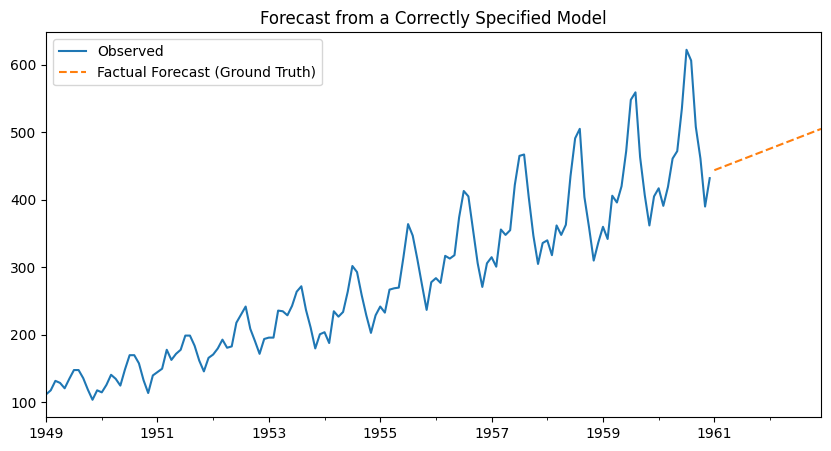

In [7]:

# Step 2: Fitting a "Ground Truth" Model 

print("\n---Fitting the definitive Ground Truth Model ---")

# 1. Define the correct causal structure for the airline data
ground_truth_structure = [
    (("passengers", 1), ("passengers", 0)),
    (("passengers", 12), ("passengers", 0)), # The key seasonal link
]

# 2. Instantiate the forecaster with the ground truth structure.
from pgmpy.estimators import BayesianEstimator
fc_truth = PgmpyDBNForecaster(
    structure=ground_truth_structure,
    max_lag=12,
    state_names=state_names_air,
    estimator=BayesianEstimator,
    estimator_kwargs={"prior_type": "BDeu", "equivalent_sample_size": 1}
)

# 3. Fit the model
fc_truth.fit(y=y_binned, fh=fh_air)
print("Fit successful.")

# 4. Generate and visualize the factual forecast. It will now be dynamic.
y_pred_binned_factual = fc_truth.predict(fh=fh_air)
y_pred_continuous_factual = y_pred_binned_factual.map(bin_centers)
df_to_transform_factual = y_pred_continuous_factual.to_frame(name=y_raw.name)
y_pred_final_factual = detrender.inverse_transform(df_to_transform_factual)[y_raw.name]

fig, ax = plt.subplots(figsize=(10, 5))
y_raw.plot(ax=ax, label="Observed")
y_pred_final_factual.plot(ax=ax, label="Factual Forecast (Ground Truth)", style='--')
ax.set_title("Forecast from a Correctly Specified Model")
ax.legend();
plt.show()

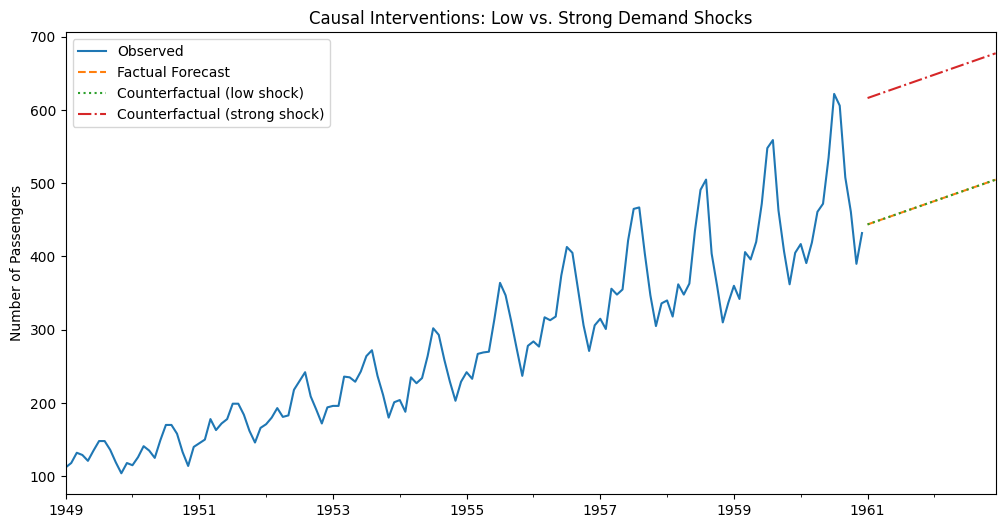

In [8]:
# Step 3: Two Flavors of Counterfactual 

from copy import deepcopy
from pgmpy.models import DiscreteBayesianNetwork
from sktime.forecasting.base import ForecastingHorizon

# 0) Monkey-patch so .copy() is a real deep copy (preserving all CPDs)
DiscreteBayesianNetwork.copy = lambda self: deepcopy(self)

# 1) Low-bin shock (bins 1 & 12 → 0) — you’ll see this overlay with the factual
shock_low = {("passengers", 1): 0, ("passengers", 12): 0}
y_low_binned = fc_truth.predict_causal(fh=fh_air, intervention=shock_low)

# 2) Strong-bin shock (bins 1 & 12 → 5) — this *will* flip the argmax to bin 5
shock_strong = {("passengers", 1): 5, ("passengers", 12): 5}
y_strong_binned = fc_truth.predict_causal(fh=fh_air, intervention=shock_strong)

# 3) Map back to continuous & de-trend
y_low_cont     = y_low_binned.map(bin_centers)
y_strong_cont  = y_strong_binned.map(bin_centers)
df_low         = y_low_cont.to_frame(name=y_raw.name)
df_strong      = y_strong_cont.to_frame(name=y_raw.name)

y_low_final    = detrender.inverse_transform(df_low)[y_raw.name]
y_strong_final = detrender.inverse_transform(df_strong)[y_raw.name]

# 4) Plot all three: factual (dashed), low shock (dotted), strong shock (dash-dot)
fig, ax = plt.subplots(figsize=(12,6))
y_raw.plot(ax=ax, label="Observed")
y_pred_final_factual.plot(ax=ax, style="--", label="Factual Forecast")
y_low_final.plot(ax=ax, style=":",  label="Counterfactual (low shock)")
y_strong_final.plot(ax=ax, style="-.", label="Counterfactual (strong shock)")

ax.set_title("Causal Interventions: Low vs. Strong Demand Shocks")
ax.set_ylabel("Number of Passengers")
ax.legend()
plt.show()


  0%|          | 0/1000000 [00:00<?, ?it/s]

Discovered edges: [('passengers_0', 'passengers_1'), ('passengers_3', 'passengers_4'), ('passengers_3', 'passengers_2'), ('passengers_4', 'passengers_5'), ('passengers_5', 'passengers_6'), ('passengers_6', 'passengers_7'), ('passengers_7', 'passengers_8'), ('passengers_8', 'passengers_9'), ('passengers_9', 'passengers_10'), ('passengers_10', 'passengers_11'), ('passengers_11', 'passengers_12'), ('passengers_12', 'passengers_0')]


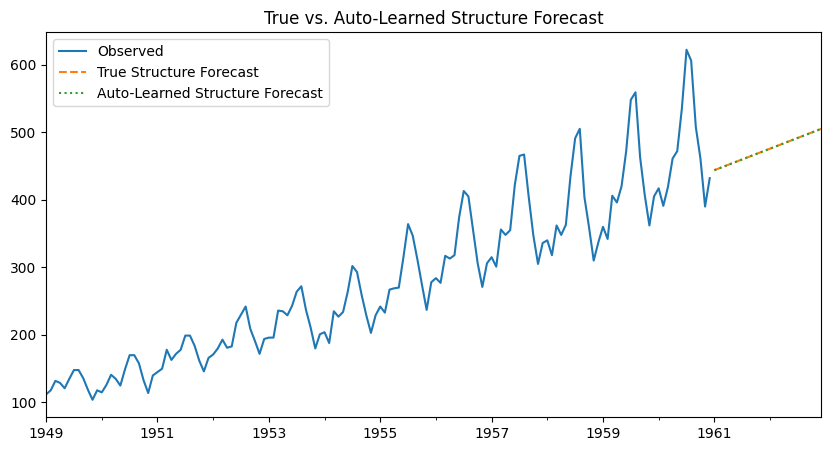

In [9]:
# Step 4: Automated Structure Learning (Airline) 

from pgmpy.estimators import HillClimbSearch

# 1) Learn structure automatically (AIC‐D) with same settings as fc_truth
fc_auto = PgmpyDBNForecaster(
    structure=None,
    auto_structure=True,
    max_lag=12,
    state_names=state_names_air,
    estimator=BayesianEstimator,
    estimator_kwargs={"prior_type":"BDeu","equivalent_sample_size":1}
)
fc_auto.fit(y=y_binned, fh=fh_air)
    
print("Discovered edges:", fc_auto.dbn_.edges())

# 2) Forecast with the auto‐learned structure
y_auto_binned = fc_auto.predict(fh=fh_air)
y_auto_cont   = y_auto_binned.map(bin_centers)
df_auto       = y_auto_cont.to_frame(name=y_raw.name)
y_auto_final  = detrender.inverse_transform(df_auto)[y_raw.name]

# 3) Plot True-structure vs Auto-structure forecasts
fig, ax = plt.subplots(figsize=(10, 5))
y_raw.plot(ax=ax, label="Observed")
y_pred_final_factual.plot(
    ax=ax, style="--", label="True Structure Forecast"
)
y_auto_final.plot(
    ax=ax, style=":", label="Auto-Learned Structure Forecast"
)
ax.set_title("True vs. Auto-Learned Structure Forecast")
ax.legend()
plt.show()


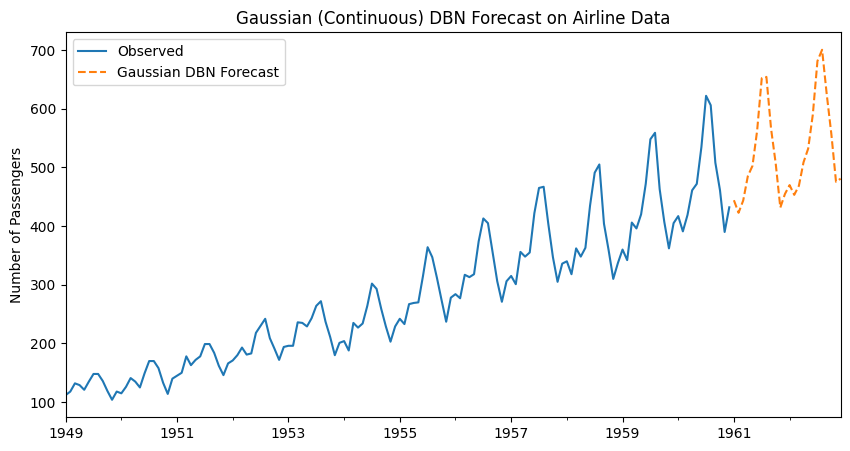

In [10]:
# Step 5: Continuous Gaussian DBN Forecasting 

import pandas as pd
from collections import deque
from sktime.utils.validation.forecasting import check_fh
import matplotlib.pyplot as plt

# 1) Prepare the detrended series named "passengers"
y_detrended = detrender.fit_transform(y_raw)  
y_detrended.name = "passengers"

# 2) Instantiate & fit the continuous DBN
fc_cont = PgmpyDBNForecaster(
    structure=ground_truth_structure,
    max_lag=12,
    continuous=True,
)
fc_cont.fit(y=y_detrended, fh=fh_air)

# 3) Build a history deque of the last `max_lag` points
history = deque(y_detrended.iloc[-fc_cont.max_lag :], maxlen=fc_cont.max_lag)

# 4) Manually roll forward, one step at a time
fh = fh_air
abs_idx = fh.to_absolute(fc_cont.cutoff).to_pandas()
preds = []
for _ in fh.to_relative(fc_cont.cutoff):
    # build evidence for EVERY lag from 1…max_lag
    evidence = {
        f"passengers_{lag}": history[-lag]
        for lag in range(1, fc_cont.max_lag + 1)
    }
    # get the conditional mean from the CPD
    mean, _ = fc_cont._gaussian_forward_inference("passengers_0", evidence)
    preds.append(mean)
    history.append(mean)

# 5) Assemble into a Series & inverse‐detrend
y_cont_pred = pd.Series(preds, index=abs_idx, name="passengers")
df_cont = y_cont_pred.to_frame(name=y_raw.name)
y_cont_final = detrender.inverse_transform(df_cont)[y_raw.name]

# 6) Plot
fig, ax = plt.subplots(figsize=(10,5))
y_raw.plot(ax=ax, label="Observed")
y_cont_final.plot(ax=ax, linestyle="--", label="Gaussian DBN Forecast")
ax.set_title("Gaussian (Continuous) DBN Forecast on Airline Data")
ax.set_ylabel("Number of Passengers")
ax.legend()
plt.show()


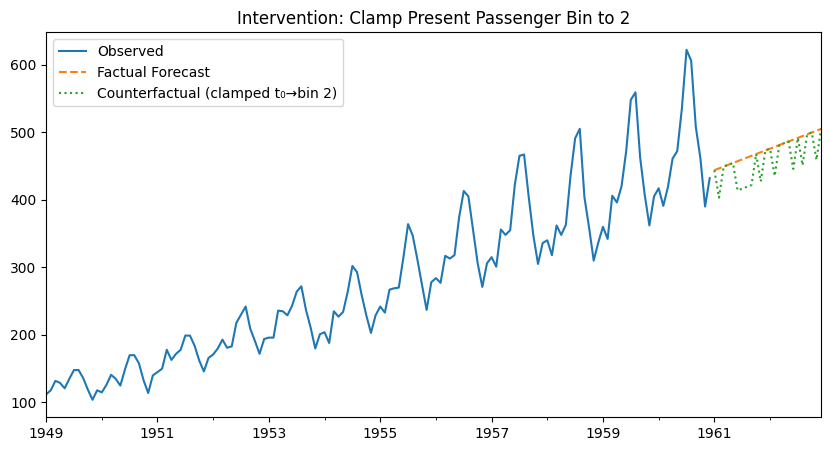

In [11]:
# Step 6: Intervention on the Target Node (lag 0) 

# Force the CURRENT passenger bin to 2 at every step
shock_target = {("passengers", 0): 2}
y_target_binned = fc_truth.predict_causal(
    fh=fh_air,
    intervention=shock_target
)

# Map back to continuous + inverse‐detrend
y_target_cont  = y_target_binned.map(bin_centers)
df_target       = y_target_cont.to_frame(name=y_raw.name)
y_target_final = detrender.inverse_transform(df_target)[y_raw.name]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
y_raw.plot(ax=ax, label="Observed")
y_pred_final_factual.plot(
    ax=ax, style="--", label="Factual Forecast"
)
y_target_final.plot(
    ax=ax, style=":", label="Counterfactual (clamped t₀→bin 2)"
)
ax.set_title("Intervention: Clamp Present Passenger Bin to 2")
ax.legend()
plt.show()


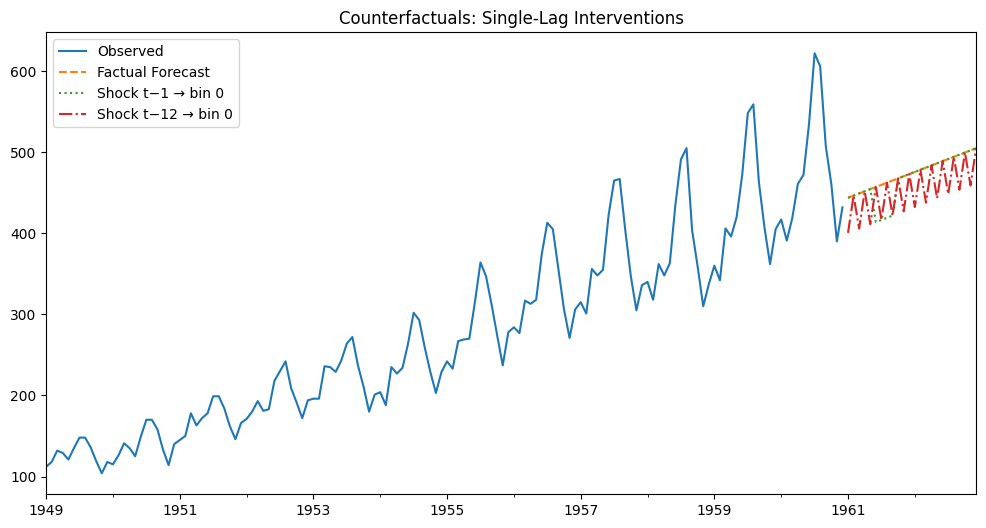

In [12]:
#  Step 7: Single‐Lag Interventions 

# Shock only the t−1 parent vs. only the t−12 parent
shock_lag1   = {("passengers", 1): 0}
shock_lag12  = {("passengers",12): 0}

y_lag1_b     = fc_truth.predict_causal(fh=fh_air, intervention=shock_lag1)
y_lag12_b    = fc_truth.predict_causal(fh=fh_air, intervention=shock_lag12)

# Map & inverse‐detrend
y_lag1_cont  = y_lag1_b.map(bin_centers)
y_lag12_cont = y_lag12_b.map(bin_centers)

y_lag1_final  = detrender.inverse_transform(
    y_lag1_cont.to_frame(name=y_raw.name)
)[y_raw.name]
y_lag12_final = detrender.inverse_transform(
    y_lag12_cont.to_frame(name=y_raw.name)
)[y_raw.name]

# Plot all three
fig, ax = plt.subplots(figsize=(12, 6))
y_raw.plot(ax=ax, label="Observed")
y_pred_final_factual.plot(
    ax=ax, style="--", label="Factual Forecast"
)
y_lag1_final.plot(
    ax=ax, style=":", label="Shock t−1 → bin 0"
)
y_lag12_final.plot(
    ax=ax, style="-.", label="Shock t−12 → bin 0"
)
ax.set_title("Counterfactuals: Single‐Lag Interventions")
ax.legend()
plt.show()
